In [1]:
from fastai.imports import * 

In [2]:
import pandas as pd
import numpy as np


Reading the data

In [3]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df = df.rename(columns = {i:i.lower() for i in df.columns})
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.isna().sum()

passengerid      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64

Processing the data

In [7]:
modes = df.mode().iloc[0]
df.fillna(modes,inplace=True)  #filling the null values of feature with the mode of that particular feature

In [8]:
df.isna().sum()

passengerid    0
survived       0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
cabin          0
embarked       0
dtype: int64

In [9]:
def process_data(df):
    df['fare'] = np.log(df['fare'] + 1)
    df['sex'] = pd.Categorical(df['sex'])
    df['embarked'] = pd.Categorical(df['embarked'])
    return df
df = process_data(df) 
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,2.110213,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,4.280593,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.188856,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.990834,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.202765,B96 B98,S


In [10]:
def classify(df):
    target = 'survived'
    numerical = [c for c in df.select_dtypes(include=np.number).columns if c!=target]
    categorical = [c for c in df.select_dtypes(exclude=np.number).columns if c!=target]
    continuous = [feature for feature in numerical if df[feature].nunique()>20]
    discrete = [feature for feature in numerical if df[feature].nunique()<=20]
    return numerical, categorical, continuous, discrete
numerical, categorical, continuous, discrete = classify(df)    

In [11]:
print('The categorical features are:', categorical)
print('The numerical features are:', numerical)

The categorical features are: ['name', 'sex', 'ticket', 'cabin', 'embarked']
The numerical features are: ['passengerid', 'pclass', 'age', 'sibsp', 'parch', 'fare']


In [12]:
cat_features = ['sex','embarked']  #categorical features
numerical_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']  #numerical features
dep_feature = ['survived']   #dependent feature or target


In [13]:
df['sex']

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: sex, Length: 891, dtype: category
Categories (2, object): ['female', 'male']

In [15]:
df['sex'].cat.codes

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Length: 891, dtype: int8

As we can see from the above output that the value of feature sex is already stored as integers. Here integers denote the indices to represent the value of feature sex which is either female or male.

Plot to study the feature sex

[Text(0.5, 1.0, 'Histogram')]

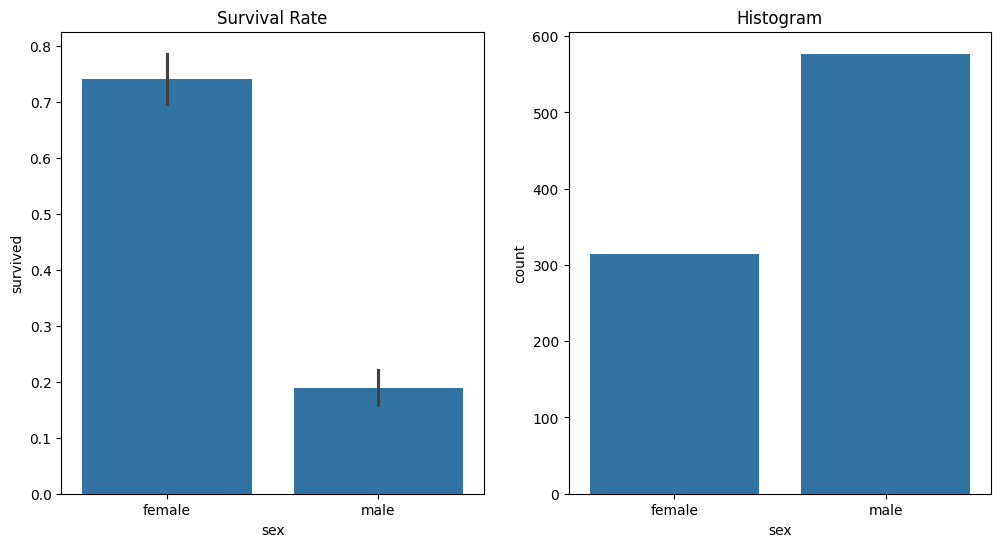

In [16]:
import seaborn as sns
fig,axes = plt.subplots(1,2,figsize=(12,6))
sns.barplot(data = df, x = 'sex', y ='survived',ax = axes[0]).set(title = 'Survival Rate')
sns.countplot(data = df, x='sex' , ax=axes[1]).set(title = 'Histogram')


We can observe from the above plot that, the feature sex is doing pretty good job at differentiating between survived and non-survived passengers, because the survival rate of female is over 70% whereas that of male is around 20%. Also , both the number of male and female passengers is over 300.

Splitting the data into training and cross_validation dataset

In [18]:
from sklearn.model_selection import train_test_split
from numpy import random
random.seed(42)
train_df,val_df = train_test_split(df,test_size = 0.25)
#applying the categorical codes on both training as well as validation dataset
train_df[cat_features] = train_df[cat_features].apply(lambda x: x.cat.codes)
val_df[cat_features] = val_df[cat_features].apply(lambda x: x.cat.codes)